In [4]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
from pathlib import Path
import os

In [5]:
# Variables that have summed components: NH4 (WD_NH4 + WD_NH3), DOC (BC + SOA + POM), SO4 (a1,a2,a3, c1,c2,c3), precip (C, L)

#Read in global model timeseries files for these variables:
daily_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2')
daily_so4_files_to_open = ['FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_NH4.nc', 
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_NH3.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a2SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a3SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c2SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c3SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.PRECC.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.PRECL.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_a1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_a4SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_c1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_c4SFWET.nc']
                           
# Concatenate directory path with each file name separately
file_paths = [daily_result_dir / file_name for file_name in daily_so4_files_to_open]

# Open multiple netCDF files as a single dataset
nc_daily = xr.open_mfdataset(file_paths, combine='nested')

#Read in BC wet dep timeseries files
result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2')

#read in POM files
daily_pom_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.pom_*SFWET.nc'
nc_daily_pom = xr.open_mfdataset(str(result_dir/daily_pom_to_open),combine='nested')

#read in SOA
soa_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_SOAvars/')
daily_soa_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.*SFWET.nc'
nc_daily_soa = xr.open_mfdataset(str(soa_result_dir/daily_soa_to_open),combine='nested')

#merge SOA and POM files together
nc_daily_all = xr.merge([nc_daily_soa, nc_daily_pom, nc_daily])
nc_daily_all

<xarray.Dataset>
Dimensions:       (time: 7671, lat: 192, lon: 288)
Coordinates:
  * lat           (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon           (lon) float64 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time          (time) datetime64[ns] 2002-01-01 2002-01-02 ... 2023-01-01
Data variables: (12/38)
    soa1_a1SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    soa1_a2SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    soa1_c1SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    soa1_c2SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    soa2_a1SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    soa2_a2SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    ...            ...
    PRECC         (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    PRECL         (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    bc_a1SFWET    (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    bc_a4SFWET    (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    bc_c1SFWET    (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    bc_c4SFWET    (time, lat, lon) float32 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              FCnudged_f09.mam.Murray.Apr11_01.2002_2023.001
    logname:           demurray
    host:              derecho1
    initial_file:      /glade/campaign/acom/acom-climate/UTLS/shawnh/archive/...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/f...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [6]:
#Subset data for only over CONUS

# Apply CONUS bounds
nc_daily_all = nc_daily_all.where(
    (nc_daily_all.lat >= 24.5) & (nc_daily_all.lat <= 49.5) & 
    (nc_daily_all.lon >= 235) & (nc_daily_all.lon <= 293), 
    drop=True
)

#Correct timestamp (offset by 1 month)
#nc_monthly_SF_conus['time2'] = pd.to_datetime(nc_monthly_SF_conus['time'].values,format='%Y-%m-%dT%H:%M:%S')+DateOffset(months=-1)

# Check the new dataset dimensions - should be smaller (and it is!)
nc_daily_all

<xarray.Dataset>
Dimensions:       (time: 7671, lat: 27, lon: 47)
Coordinates:
  * lat           (lat) float64 24.97 25.92 26.86 27.8 ... 47.59 48.53 49.48
  * lon           (lon) float64 235.0 236.2 237.5 238.8 ... 290.0 291.2 292.5
  * time          (time) datetime64[ns] 2002-01-01 2002-01-02 ... 2023-01-01
Data variables: (12/38)
    soa1_a1SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    soa1_a2SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    soa1_c1SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    soa1_c2SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    soa2_a1SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    soa2_a2SFWET  (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    ...            ...
    PRECC         (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    PRECL         (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    bc_a1SFWET    (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    bc_a4SFWET    (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    bc_c1SFWET    (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
    bc_c4SFWET    (time, lat, lon) float32 dask.array<chunksize=(7671, 27, 47), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              FCnudged_f09.mam.Murray.Apr11_01.2002_2023.001
    logname:           demurray
    host:              derecho1
    initial_file:      /glade/campaign/acom/acom-climate/UTLS/shawnh/archive/...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/f...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [7]:
#Calculate percents of each variable

#NH4: (WD_NH4 + WD_NH3) --> this needs to be corrected for the mixture of negative and positive values first
nc_daily_all['WD_NH4_corr'] = xr.where(nc_daily_all['WD_NH4'] > 0, 0, nc_daily_all['WD_NH4'])
nc_daily_all['WD_NH3_corr'] = xr.where(nc_daily_all['WD_NH3'] > 0, 0, nc_daily_all['WD_NH3'])
nc_daily_all['WD_NH3_corr'] = nc_daily_all['WD_NH3_corr']  * -1
nc_daily_all['WD_NH4_corr'] = nc_daily_all['WD_NH4_corr']  * -1
#nc_daily_all['WD_NH4_corr'] = nc_daily_all['WD_NH4_corr'].replace(-0.0, 0.0)
#nc_daily_all['WD_NH3_corr'] = nc_daily_all['WD_NH3_corr'].replace(-0.0, 0.0)
nc_daily_all['NH4_total'] = nc_daily_all['WD_NH4_corr'] + nc_daily_all['WD_NH3_corr'] 
nc_daily_all['perc_NH4'] = nc_daily_all['WD_NH4_corr'] / nc_daily_all['NH4_total']
nc_daily_all['perc_NH3'] = nc_daily_all['WD_NH3_corr'] / nc_daily_all['NH4_total']

#Precip: PRECC + PRECL
nc_daily_all['precip_total'] = nc_daily_all['PRECC'] + nc_daily_all['PRECL'] 
nc_daily_all['perc_PRECC'] = nc_daily_all['PRECC'] / nc_daily_all['precip_total']
nc_daily_all['perc_PRECL'] = nc_daily_all['PRECL'] / nc_daily_all['precip_total']

#DOC (BC + SOA + POM)
nc_daily_all['soa_a_total'] = nc_daily_all['soa1_a1SFWET'] + nc_daily_all['soa1_a2SFWET']  + nc_daily_all['soa2_a1SFWET'] + nc_daily_all['soa2_a2SFWET'] + nc_daily_all['soa3_a1SFWET'] + nc_daily_all['soa3_a2SFWET'] + nc_daily_all['soa4_a1SFWET'] + nc_daily_all['soa4_a2SFWET']  + nc_daily_all['soa5_a1SFWET'] + nc_daily_all['soa5_a2SFWET'] 

nc_daily_all['soa_c_total'] =  nc_daily_all['soa1_c1SFWET'] + nc_daily_all['soa1_c2SFWET'] + nc_daily_all['soa2_c1SFWET'] +  nc_daily_all['soa2_c2SFWET']  + nc_daily_all['soa3_c1SFWET'] + nc_daily_all['soa3_c2SFWET']  + nc_daily_all['soa4_c1SFWET'] + nc_daily_all['soa4_c2SFWET'] + nc_daily_all['soa5_c1SFWET'] + nc_daily_all['soa5_c2SFWET'] 

nc_daily_all['pom_a_total'] = nc_daily_all['pom_a1SFWET'] + nc_daily_all['pom_a4SFWET'] 
nc_daily_all['pom_c_total'] = nc_daily_all['pom_c1SFWET'] + nc_daily_all['pom_c4SFWET']

nc_daily_all['bc_a_total'] = nc_daily_all['bc_a1SFWET'] + nc_daily_all['bc_a4SFWET'] 
nc_daily_all['bc_c_total'] = nc_daily_all['bc_c1SFWET'] + nc_daily_all['bc_c4SFWET']

nc_daily_all['DOC_total'] = nc_daily_all['soa_a_total'] + nc_daily_all['soa_c_total'] + nc_daily_all['pom_a_total'] + nc_daily_all['pom_c_total'] + nc_daily_all['bc_a_total'] + nc_daily_all['bc_c_total']

nc_daily_all['perc_soa_a'] = nc_daily_all['soa_a_total'] / nc_daily_all['DOC_total']
nc_daily_all['perc_soa_c'] = nc_daily_all['soa_c_total'] / nc_daily_all['DOC_total']
nc_daily_all['perc_pom_a'] = nc_daily_all['pom_a_total'] / nc_daily_all['DOC_total']
nc_daily_all['perc_pom_c'] = nc_daily_all['pom_c_total'] / nc_daily_all['DOC_total']
nc_daily_all['perc_bc_a']=  nc_daily_all['bc_a_total'] / nc_daily_all['DOC_total']
nc_daily_all['perc_bc_c']= nc_daily_all['bc_c_total'] / nc_daily_all['DOC_total']

#SO4 (a1,a2,a3, c1,c2,c3)
nc_daily_all['so4_a_total'] = nc_daily_all['so4_a1SFWET'] + nc_daily_all['so4_a2SFWET'] + nc_daily_all['so4_a3SFWET'] 
nc_daily_all['so4_c_total'] =nc_daily_all['so4_c1SFWET'] + nc_daily_all['so4_c2SFWET'] + nc_daily_all['so4_c3SFWET']
nc_daily_all['so4_total'] = nc_daily_all['so4_a_total'] + nc_daily_all['so4_c_total']
nc_daily_all['perc_so4_a'] = nc_daily_all['so4_a_total'] / nc_daily_all['so4_total']
nc_daily_all['perc_so4_c'] = nc_daily_all['so4_c_total'] / nc_daily_all['so4_total']

nc_daily_all

#Create a CONUS averaged value over time
ds_mean = nc_daily_all.mean(dim=["lat", "lon"])

/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


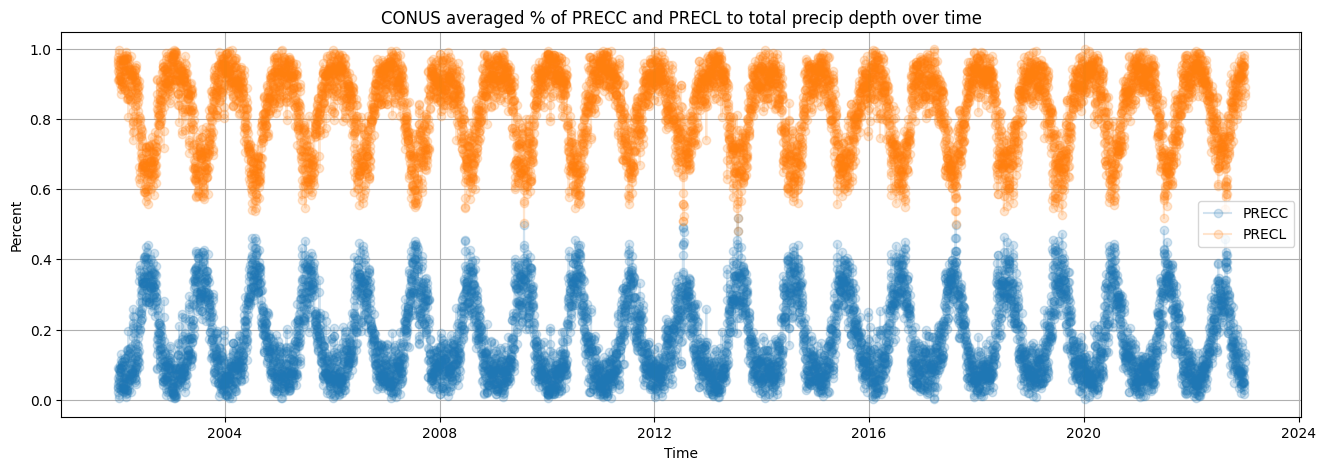

In [5]:
# Precip plot
plt.figure(figsize=(16, 5))
plt.plot(ds_mean["time"], ds_mean['perc_PRECC'].values, marker='o', linestyle='-', alpha = 0.2, label = 'PRECC')
plt.plot(ds_mean["time"], ds_mean['perc_PRECL'].values, marker='o', linestyle='-', alpha = 0.2, label = 'PRECL')
plt.xlabel("Time")
plt.ylabel("Percent")
plt.title("CONUS averaged % of PRECC and PRECL to total precip depth over time")
plt.grid(True)
plt.legend()
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Precip_proportion_trend.jpg', format='jpg', dpi=300)  
plt.show()

/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


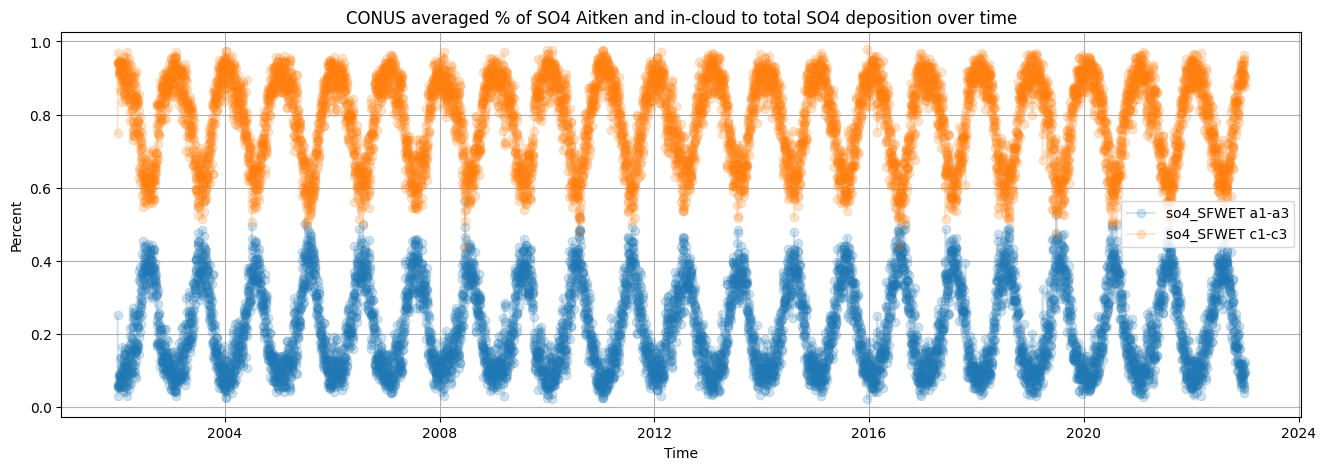

In [6]:
# SO4 plot
plt.figure(figsize=(16, 5))
plt.plot(ds_mean["time"], ds_mean['perc_so4_a'].values, marker='o', linestyle='-', alpha = 0.2, label = 'so4_SFWET a1-a3')
plt.plot(ds_mean["time"], ds_mean['perc_so4_c'].values, marker='o', linestyle='-', alpha = 0.2, label = 'so4_SFWET c1-c3')
plt.xlabel("Time")
plt.ylabel("Percent")
plt.title("CONUS averaged % of SO4 Aitken and in-cloud to total SO4 deposition over time")
plt.grid(True)
plt.legend()
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/SO4_proportion_trend.jpg', format='jpg', dpi=300)  
plt.show()

/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


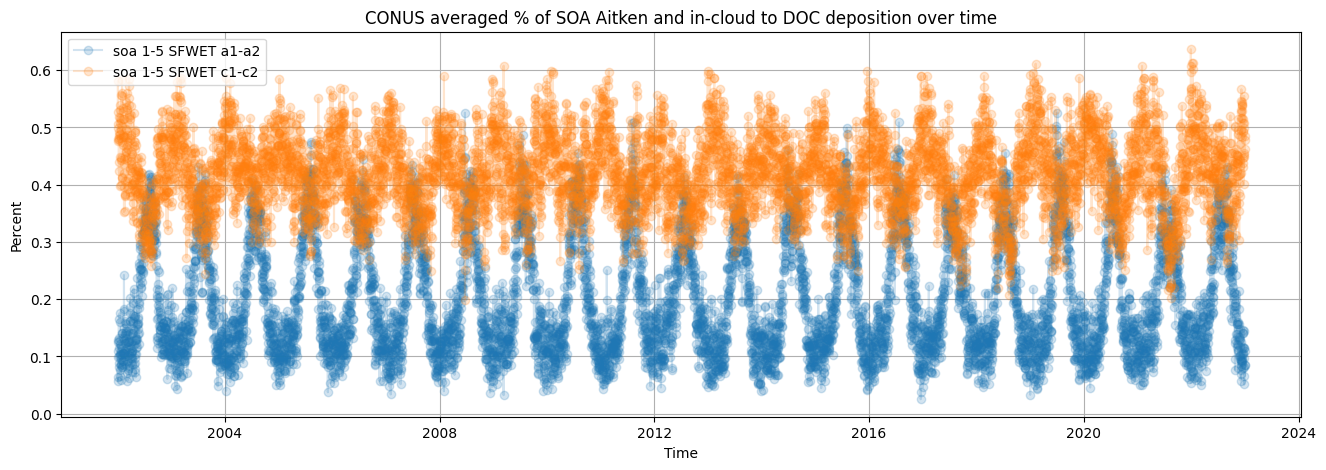

In [7]:
#DOC (SOA)
plt.figure(figsize=(16, 5))
plt.plot(ds_mean["time"], ds_mean['perc_soa_a'].values, marker='o', linestyle='-', alpha = 0.2, label = 'soa 1-5 SFWET a1-a2')
plt.plot(ds_mean["time"], ds_mean['perc_soa_c'].values, marker='o', linestyle='-', alpha = 0.2, label = 'soa 1-5 SFWET c1-c2')
plt.xlabel("Time")
plt.ylabel("Percent")
plt.title("CONUS averaged % of SOA Aitken and in-cloud to DOC deposition over time")
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/SOA_proportion_trend.jpg', format='jpg', dpi=300)  
plt.grid(True)
plt.legend()
plt.show()

/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


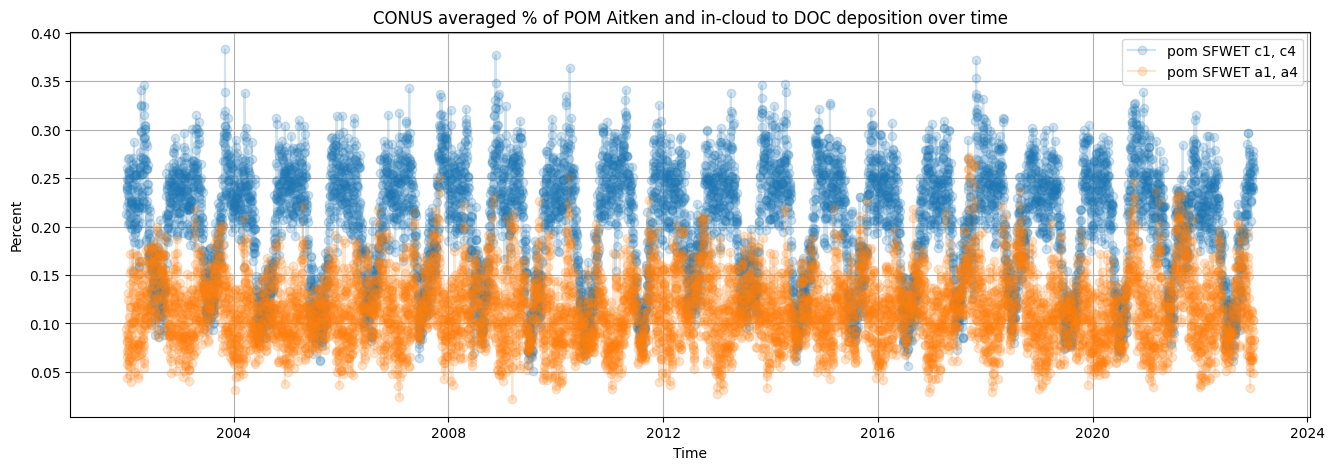

In [8]:
#DOC ( POM)
plt.figure(figsize=(16, 5))
plt.plot(ds_mean["time"], ds_mean['perc_pom_c'].values, marker='o', linestyle='-', alpha = 0.2, label = 'pom SFWET c1, c4')
plt.plot(ds_mean["time"], ds_mean['perc_pom_a'].values, marker='o', linestyle='-', alpha = 0.2, label = 'pom SFWET a1, a4')
#plt.plot(ds_mean["time"], ds_mean['perc_bc_a'].values, marker='o', linestyle='-', alpha = 0.2, label = 'bc SFWET a1, a4')
#plt.plot(ds_mean["time"], ds_mean['perc_bc_c'].values, marker='o', linestyle='-', alpha = 0.2, label = 'bc SFWET c1, c4')
plt.xlabel("Time")
plt.ylabel("Percent")
plt.title("CONUS averaged % of POM Aitken and in-cloud to DOC deposition over time")
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/POM_proportion_trend.jpg', format='jpg', dpi=300)  
plt.grid(True)
plt.legend()
plt.show()

/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


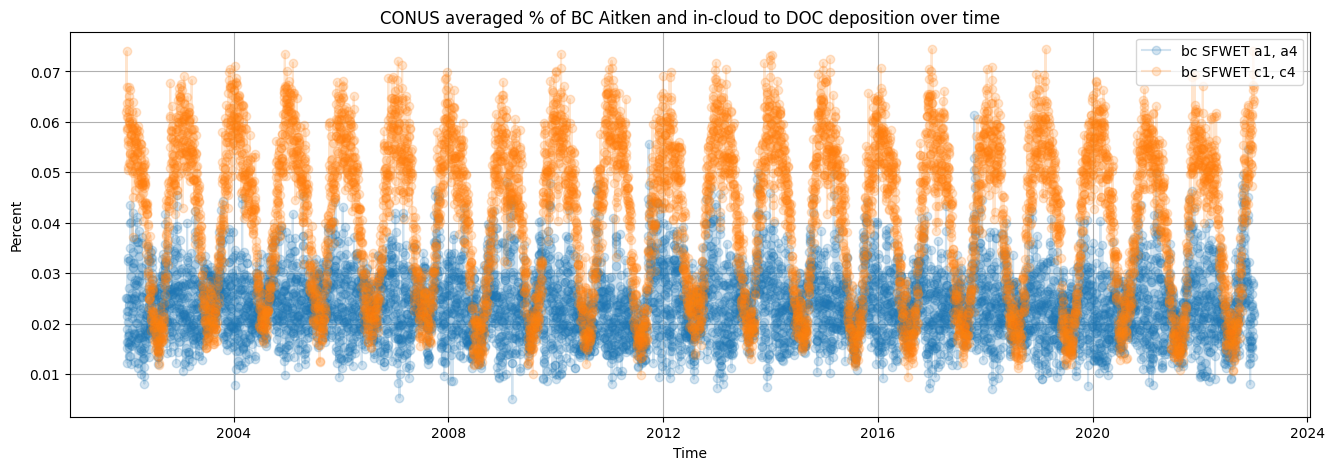

In [9]:
#DOC (BC)
plt.figure(figsize=(16, 5))
plt.plot(ds_mean["time"], ds_mean['perc_bc_a'].values, marker='o', linestyle='-', alpha = 0.2, label = 'bc SFWET a1, a4')
plt.plot(ds_mean["time"], ds_mean['perc_bc_c'].values, marker='o', linestyle='-', alpha = 0.2, label = 'bc SFWET c1, c4')
plt.xlabel("Time")
plt.ylabel("Percent")
plt.title("CONUS averaged % of BC Aitken and in-cloud to DOC deposition over time")
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/BC_proportion_trend.jpg', format='jpg', dpi=300)  
plt.grid(True)
plt.legend()
plt.show()

/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


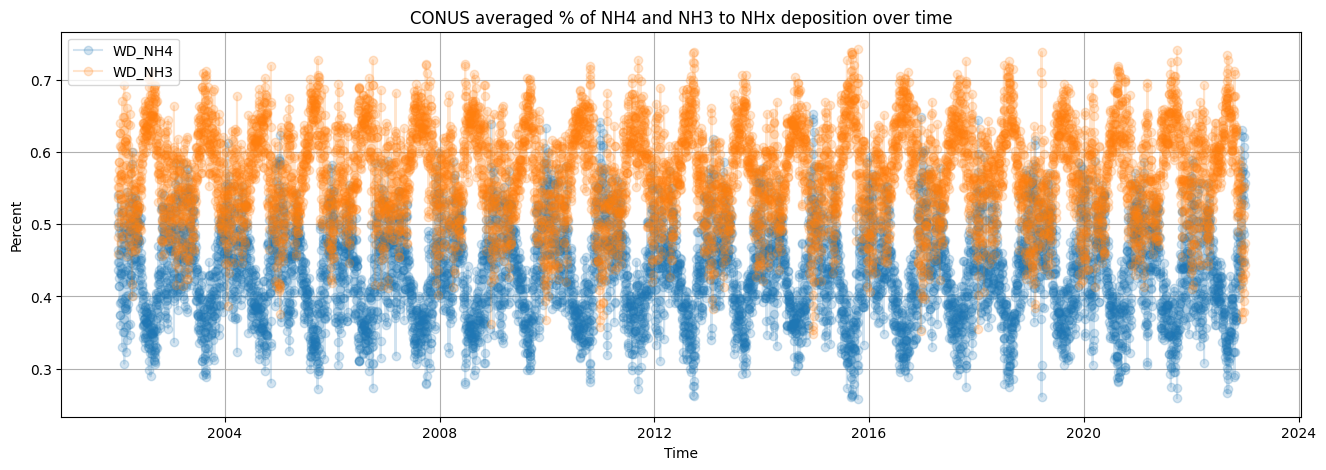

In [15]:
# NH4 plot
plt.figure(figsize=(16, 5))
plt.plot(ds_mean["time"], ds_mean['perc_NH4'].values, marker='o', linestyle='-', alpha = 0.2, label = 'WD_NH4')
plt.plot(ds_mean["time"], ds_mean['perc_NH3'].values, marker='o', linestyle='-', alpha = 0.2, label = 'WD_NH3')
plt.xlabel("Time")
plt.ylabel("Percent")
plt.title("CONUS averaged % of NH4 and NH3 to NHx deposition over time")
plt.grid(True)
plt.legend()
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/NH4_NH3_proportion_trend.jpg', format='jpg', dpi=300)  
plt.show()

In [11]:
ds_mean_time = ds_mean.mean()
print(ds_mean_time['perc_PRECC'].values) # 17
print(ds_mean_time['perc_PRECL'].values) #83

print(ds_mean_time['perc_NH4'].values) #43
print(ds_mean_time['perc_NH3'].values) #57

print(ds_mean_time['perc_bc_a'].values)# 2
print(ds_mean_time['perc_bc_c'].values)#4
print(ds_mean_time['perc_soa_a'].values) #20
print(ds_mean_time['perc_soa_c'].values) #42
print(ds_mean_time['perc_pom_a'].values)#11
print(ds_mean_time['perc_pom_c'].values) # 20

print(ds_mean_time['perc_so4_a'].values)# 21
print(ds_mean_time['perc_so4_c'].values)#79



/glade/u/apps/opt/conda/envs/npl-2023a/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


0.17393312
0.82606685
0.42886943
0.5711306
0.02358025
0.040924937
0.19967198
0.4180304
0.114789836
0.20300259
0.21484412
0.78515595
